# Was ist der System Usability Scale (SUS)?

Der System Usability Scale (SUS) ist ein kurzes, zuverlässiges Messinstrument zur Erfassung der Gebrauchstauglichkeit (Usability) von interaktiven Systemen. Entwickelt wurde es von John Brooke (Digital Equipment) in den 1980er Jahren und wird seitdem weit verbreitet in Usability‑Evaluierungen, Benchmarking und Produktentscheidungen eingesetzt.

## Wesentliches in Kürze:

- Der SUS besteht aus 10 Fragen mit einer 5‑stufigen Likert‑Skala (1 = Stimme überhaupt nicht zu, 5 = Stimme voll zu).
- Die Fragen sind abwechselnd positiv und negativ formuliert. Damit nach der Auswertung ein höherer Wert immer bessere Usability bedeutet, werden die Rohantworten zuerst in Werte von 0–4 umgerechnet und dann aufsummiert (→ siehe 
 unten).
- Obwohl kurz, liefert der SUS robuste, vergleichbare Kennzahlen zur Usability und ist nützlich für Evaluationen, Trendmessungen und Benchmarking zwischen Versionen/Produkten.
- In diesem Notebook sind gängige Interpretationsrichtlinien (z. B. Sauro & Lewis) implementiert, die Mittelwerte in Kategorien wie Inakzeptabel, Marginal, OK, Gut, Exzellent einordnen.

### Was bedeutet "Normalisierung" hier?

Normalisierung heißt in diesem Notebook: die rohen Antworten (1–5) so umzuwandeln, dass alle Items die gleiche Richtung (größer = besser) haben und auf einer gemeinsamen Skala 0–4 liegen. Das macht die Antworten vergleichbar und erlaubt anschließend, die 10 Werte zu summieren.

- Für positive Items (Q1, Q3, Q5, Q7, Q9): normalisierter Wert = Antwort − 1
  - Beispiel: Antwort 4 → 4 − 1 = 3 (Skala 0..4).
- Für negative Items (Q2, Q4, Q6, Q8, Q10): normalisierter Wert = 5 − Antwort
  - Beispiel: Antwort 4 → 5 − 4 = 1 (Skala 0..4).

Nach der Normalisierung hat jedes Item einen Wert zwischen 0 und 4. Die 10 Werte werden addiert → Summe 0–40. Diese Summe wird mit 2.5 multipliziert, um auf die geläufige 0–100 Skala zu kommen (z. B. Summe 31 → 31 × 2.5 = 77.5).

Kurze schematische Übersicht (Roh → normalisiert):

- Positives Item: 1 → 0, 2 → 1, 3 → 2, 4 → 3, 5 → 4  (Formel: Antwort − 1)
- Negatives Item: 1 → 4, 2 → 3, 3 → 2, 4 → 1, 5 → 0  (Formel: 5 − Antwort)

Kurzes Rechenbeispiel (manuell):

Angenommene Antworten (Q1..Q10):  [3, 2, 4, 1, 5, 2, 4, 2, 5, 3]

- Positive Items (Q1,Q3,Q5,Q7,Q9): 3→2, 4→3, 5→4, 4→3, 5→4 → Summe = 16
- Negative Items (Q2,Q4,Q6,Q8,Q10): 2→3, 1→4, 2→3, 2→3, 3→2 → Summe = 15
- Gesamtsumme = 16 + 15 = 31 → SUS = 31 × 2.5 = 77.5 → Interpretation: Gut (B).

Hinweis zur Robustheit (wie im Notebook gehandhabt):

- Ungültige oder nicht‑zahlige Einträge werden in Pandas zu NaN konvertiert (pd.to_numeric mit errors='coerce').
- Zeilen mit fehlenden Antworten in den 10 SUS‑Items werden standardmäßig entfernt (dropna), damit die Berechnung sauber bleibt.
- Alternativ könnte man "Imputation" verwenden — das heißt, fehlende Item‑Werte durch plausible Ersatzwerte zu schätzen (z. B. Pro‑Rating: Hochskalierung der beantworteten Items, oder Multiple Imputation zur Berücksichtigung von Unsicherheit). Diese Option ist hier nicht implementiert.

Quellen & weiterführende Literatur (Auswahl):

- [Brooke, J. (1995). SUS: A quick and dirty usability scale.](https://www.researchgate.net/publication/228593520_SUS_A_quick_and_dirty_usability_scale) (Ursprung des Instruments).
- [Sauro, J., & Lewis, J. R. (2016). Quantifying the User Experience: Practical Statistics for User Research.](https://scispace.com/pdf/quantifying-the-user-experience-c0m621ep8r.pdf) (Interpretation & Statistik).
- [Bangor, Kortum & Miller (2008). An empirical evaluation of the System Usability Scale.](https://2024.sci-hub.se/6915/a99810f9ec5ad833799508989b8431fc/10.1080@10447310802205776.pdf) (Empirische Validierung und Hinweise zur Interpretation).

Hinweis zur Nutzung dieses Notebooks: Es lädt einen Google‑Forms/CSV‑Export, ordnet Spalten zu (Q1..Q10), berechnet die SUS‑Werte pro Proband und zeigt statistische Kennzahlen sowie eine interpretative Visualisierung.

## Die 10 SUS‑Fragen

Antworten werden auf einer Skala von 1 (Stimme überhaupt nicht zu) bis 5 (Stimme voll zu) gegeben. Fragen 2, 4, 6, 8 und 10 sind negativ formuliert (invertiert bei der Normalisierung).

1. Ich denke, dass ich dieses System gerne regelmäßig nutzen würde.
2. Ich fand das System unnötig komplex.
3. Ich fand das System einfach zu benutzen.
4. Ich denke, dass ich technische Unterstützung benötigen würde, um das System zu benutzen.
5. Ich fand die verschiedenen Funktionen im System gut integriert.
6. Ich fand, es gab zu viele Inkonsistenzen im System.
7. Ich stelle mir vor, dass die meisten Leute sehr schnell lernen würden, das System zu benutzen.
8. Ich fand das System sehr umständlich zu benutzen.
9. Ich fühlte mich sehr sicher im Umgang mit dem System.
10. Ich musste eine Menge lernen, bevor ich anfangen konnte, mit dem System zu arbeiten.

Hinweis: Negative Items (2,4,6,8,10) werden bei der Auswertung invertiert: normalisierter Wert = 5 − Antwort. Positive Items: normalisierter Wert = Antwort − 1.

In [46]:
# Hilfstabelle: Wie werden Rohantworten (1-5) normalisiert?
import pandas as pd
raw = [1,2,3,4,5]
pos = [r - 1 for r in raw]  # positive items: Antwort - 1
neg = [5 - r for r in raw]  # negative items: 5 - Antwort
df_norm = pd.DataFrame({'Roh': raw, 'Positiv (Antwort-1)': pos, 'Negativ (5-Antwort)': neg})
print('Normalisierungstabelle (Roh -> normalisiert):')
print(df_norm.to_string(index=False))

Normalisierungstabelle (Roh -> normalisiert):
 Roh  Positiv (Antwort-1)  Negativ (5-Antwort)
   1                    0                    4
   2                    1                    3
   3                    2                    2
   4                    3                    1
   5                    4                    0


In [47]:
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn-Stil für akademisch ansprechende Grafiken setzen
sns.set_theme(style="whitegrid")

In [48]:
# Anzeigeoptionen: komplette Lists/Tables in Outputs anzeigen (keine Kürzung)
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)
np.set_printoptions(threshold=np.inf)
print("Hinweis: Pandas/Numpy Anzeigeoptionen gesetzt: volle Listen/Tabellen werden gezeigt.")

Hinweis: Pandas/Numpy Anzeigeoptionen gesetzt: volle Listen/Tabellen werden gezeigt.


In [49]:
# Definieren Sie den Dateinamen Ihres Exports
# (Google Forms exportiert oft als .csv-Datei der verknüpften Tabelle)
DATEINAME = 'sus_google_forms_export.csv'

# Lade-Funktion mit Guard-Clauses
path = Path(DATEINAME)
if not path.exists():
    print(f"FEHLER: Die Datei '{DATEINAME}' wurde nicht im Verzeichnis gefunden: {path.resolve()}")
    raise SystemExit(1)

try:
    df = pd.read_csv(path)
except Exception as e:
    print(f"Ein unerwarteter Fehler beim Laden ist aufgetreten: {e}")
    raise

# --- START: Robustere automatische Spalten-Bereinigung ---

def mappe_spaltennamen(col_name_raw):
    """
    Versucht aus verschiedenen Varianten eines Spaltennamens eine saubere Bezeichnung zu machen, z.B. 'Q1', 'Q10' oder 'Proband_ID'.
    Diese Funktion ist robuster gegenüber Formaten wie 'Q1:', 'Q1 - Frage' oder ' q1 '.
    """

    col_name = str(col_name_raw).strip()
    col_name_lower = col_name.lower()

    # Proband-ID Varianten abfangen (z.B. 'Proband_ID' oder 'Proband ID')
    if re.search(r'proband[_\s]?id', col_name, re.IGNORECASE):
        return 'Proband_ID'

    # Keyword-basiertes Mapping für lange Google-Forms-Fragetexte (Fallback)
    keyword_map = {
        'regelmäßig zu nutzen': 'Q1',
        'regelmaessig zu nutzen': 'Q1',  # alternative spelling without umlaut
        'unnötig komplex': 'Q2',
        'unnoetig komplex': 'Q2',
        'einfach zu nutzen': 'Q3',
        'technischen support': 'Q4',
        'gut integriert': 'Q5',
        'zu viele inkonsistenzen': 'Q6',
        'schnell zu beherrschen': 'Q7',
        'sehr umständlich': 'Q8',
        'sehr umstaendlich': 'Q8',
        'sehr sicher gefühlt': 'Q9',
        'sehr sicher gefuehlt': 'Q9',
        'menge dinge lernen': 'Q10',
        'lernen': 'Q10'  # last-resort for variants
    }
    for kw, target in keyword_map.items():
        if kw in col_name_lower:
            return target

    # Match für Q1..Q10 (akzeptiert 'Q1:', 'Q1 -', 'Q1)', 'q10' etc.)
    m = re.search(r'\bq\s*[:\)\.-]*\s*(10|[1-9])\b', col_name, re.IGNORECASE)
    if m:
        return f"Q{m.group(1)}"

    # Falls keine Regel zutrifft, Originalnamen beibehalten
    return col_name

# Wende das Mapping an
df_clean = df.rename(columns=mappe_spaltennamen)

# Falls keine Proband_ID-Spalte vorhanden ist, generiere eine automatisch
if 'Proband_ID' not in df_clean.columns:
    df_clean['Proband_ID'] = [f"P{str(i+1).zfill(3)}" for i in range(len(df_clean))]
    print("Hinweis: 'Proband_ID' war nicht vorhanden und wurde automatisch als P001.. erzeugt.")

# --- ENDE: Spalten-Bereinigung ---

# Überprüfung der Ergebnisse
print("--- Analyse der Spaltennamen ---")
print("Original-Spaltennamen (voll):")
print(df.columns.tolist())
print("Bereinigte Spaltennamen (voll):")
print(df_clean.columns.tolist())

required_cols = ['Proband_ID', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
missing_cols = [col for col in required_cols if col not in df_clean.columns]
if missing_cols:
    print(f"\nWARNUNG: Folgende Spalten fehlen nach der Bereinigung: {missing_cols}")
    print("Bitte überprüfen Sie die Mapping-Regeln oder die CSV-Kopfzeilen.")
else:
    print("\nSTATUS: Alle 10 SUS-Items und die Proband_ID wurden erfolgreich zugeordnet.")

Hinweis: 'Proband_ID' war nicht vorhanden und wurde automatisch als P001.. erzeugt.
--- Analyse der Spaltennamen ---
Original-Spaltennamen (voll):
['Zeitstempel', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich kann mir sehr gut vorstellen, das System regelmäßig zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich empfinde das System als unnötig komplex.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich empfinde das System als einfach zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich denke, dass ich technischen Support brauchen würde, um das System zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich finde, dass die verschiedenen Funktionen des Systems gut integriert sind.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich finde, dass es im System zu viele Inkonsistenzen gibt.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich kann mir vorstellen, dass die meisten Leute das System schnell zu beherrschen lernen.]',

In [50]:
# Kurzer Validierungs-Check: prüfen, ob Q1..Q10 und Proband_ID vorhanden sind
print("\n--- Kurzer Validierungs-Check ---")
print("Spalten in df_clean:")
print(df_clean.columns.tolist())

required_cols = ['Proband_ID','Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10']
missing = [c for c in required_cols if c not in df_clean.columns]
if missing:
    print("FEHLER: Fehlende Spalten:", missing)
else:
    print("OK: Alle benötigten Spalten sind vorhanden.")

print(f"Anzahl Zeilen in df_clean: {len(df_clean)}")


--- Kurzer Validierungs-Check ---
Spalten in df_clean:
['Zeitstempel', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Proband_ID']
OK: Alle benötigten Spalten sind vorhanden.
Anzahl Zeilen in df_clean: 13


In [51]:
# Wir verwenden das bereinigte DataFrame 'df_clean' von Zelle 2
df_calc = df_clean.copy()

# 1. Listen der positiven (ungeraden) und negativen (geraden) Items
positive_cols = ['Q1', 'Q3', 'Q5', 'Q7', 'Q9']
negative_cols = ['Q2', 'Q4', 'Q6', 'Q8', 'Q10']
required_qs = positive_cols + negative_cols

# 2. Sicherstellen, dass die erforderlichen Spalten vorhanden sind
missing_qs = [c for c in required_qs if c not in df_calc.columns]
if missing_qs:
    raise SystemExit(f"Fehlende Q-Spalten für die Berechnung: {missing_qs}")

# 3. Typkonvertierung (robust) - nicht-konvertierbare Werte werden zu NaN
df_calc[required_qs] = df_calc[required_qs].apply(pd.to_numeric, errors='coerce')

# 4. Wertebereich prüfen (erwartet: 1..5). Werte außerhalb werden gemeldet
out_of_range = ((df_calc[required_qs] < 1) | (df_calc[required_qs] > 5)).any(axis=1)
if out_of_range.any():
    n_bad = int(out_of_range.sum())
    print(f"WARNUNG: {n_bad} Zeilen enthalten Werte außerhalb des erwarteten Bereichs 1..5. Diese Zeilen werden weiterhin behandelt (NaN/Drop), bitte prüfen.")

# 5. Fehlende Werte: lasse Entscheidung hier, wir droppen Zeilen mit mindestens einem fehlenden Q-Wert
n_before = len(df_calc)
df_calc = df_calc.dropna(subset=required_qs).reset_index(drop=True)
n_after = len(df_calc)
print(f"Zeilen vor Bereinigung: {n_before}, nach Drop von NaNs in Qs: {n_after} (entfernt: {n_before - n_after})")

# 6. Normalisierung (vektorisiert)
# Positive Items: Wert - 1; Negative Items: 5 - Wert
df_calc[positive_cols] = df_calc[positive_cols] - 1
df_calc[negative_cols] = 5 - df_calc[negative_cols]

# 7. Summenbildung und Multiplikation
normalized_cols = positive_cols + negative_cols
df_calc['SUS_Summe_0_40'] = df_calc[normalized_cols].sum(axis=1)
df_calc['SUS_Score_0_100'] = df_calc['SUS_Summe_0_40'] * 2.5

print("\nBerechnung abgeschlossen. Daten inkl. SUS-Score (voll):")
print(df_calc[['Proband_ID', 'SUS_Summe_0_40', 'SUS_Score_0_100']].to_string(index=False))

Zeilen vor Bereinigung: 13, nach Drop von NaNs in Qs: 13 (entfernt: 0)

Berechnung abgeschlossen. Daten inkl. SUS-Score (voll):
Proband_ID  SUS_Summe_0_40  SUS_Score_0_100
      P001              29             72.5
      P002              29             72.5
      P003              33             82.5
      P004              33             82.5
      P005              28             70.0
      P006              31             77.5
      P007              36             90.0
      P008              31             77.5
      P009              22             55.0
      P010              31             77.5
      P011              33             82.5
      P012              22             55.0
      P013              31             77.5


In [52]:
print("--- Statistische Gesamtauswertung (Alle Probanden) ---")

# Wir verwenden jetzt das berechnete DataFrame 'df_calc'
if 'SUS_Score_0_100' not in df_calc.columns:
    raise SystemExit('SUS_Score_0_100 fehlt im DataFrame; bitte vorher Zelle zur Berechnung ausführen.')

sus_stats = df_calc['SUS_Score_0_100'].describe()
mean_score = float(sus_stats['mean'])
std_dev = float(sus_stats['std'])
n_count = int(sus_stats['count'])
median_score = float(sus_stats['50%'])

# 95% Konfidenzintervall für den Mittelwert (approx. z=1.96)
import math
se = std_dev / math.sqrt(n_count) if n_count > 0 else float('nan')
ci_lower = mean_score - 1.96 * se
ci_upper = mean_score + 1.96 * se

print(sus_stats)
print("\n--- Zusammenfassung (Dashboard) ---")
print(f"Anzahl Probanden (n):     {n_count}")
print(f"SUS Score (Mittelwert):    {mean_score:.2f} (95% CI: {ci_lower:.2f} - {ci_upper:.2f})")
print(f"Standardabweichung (SD):   {std_dev:.2f}")
print(f"Median:                    {median_score:.2f}")
print(f"Minimaler Score:           {sus_stats['min']:.2f}")
print(f"Maximaler Score:           {sus_stats['max']:.2f}")

# Interpretation des Mittelwerts (Sauro-Lewis)
if mean_score < 51:
    interpretation = "Inakzeptabel (F)"
elif mean_score < 68:
    interpretation = "Marginal (D)"
elif mean_score < 74:
    interpretation = "OK (C)"
elif mean_score < 80.3:
    interpretation = "Gut (B)"
else:
    interpretation = "Exzellent (A)"

print(f"\nInterpretation (Mittelwert): {interpretation}")

--- Statistische Gesamtauswertung (Alle Probanden) ---
count    13.000000
mean     74.807692
std      10.229733
min      55.000000
25%      72.500000
50%      77.500000
75%      82.500000
max      90.000000
Name: SUS_Score_0_100, dtype: float64

--- Zusammenfassung (Dashboard) ---
Anzahl Probanden (n):     13
SUS Score (Mittelwert):    74.81 (95% CI: 69.25 - 80.37)
Standardabweichung (SD):   10.23
Median:                    77.50
Minimaler Score:           55.00
Maximaler Score:           90.00

Interpretation (Mittelwert): Gut (B)


In [53]:
# Interpretation: Label/Grade für SUS-Scores hinzufügen und Report erzeugen
def interpret_sus(score):
    """Gibt (Label, Grade) zurück basierend auf konventionellen Schwellen (Sauro/Lewis)."""
    if score < 51:
        return ('Inakzeptabel (F)', 'F')
    elif score < 68:
        return ('Marginal (D)', 'D')
    elif score < 74:
        return ('OK (C)', 'C')
    elif score < 80.3:
        return ('Gut (B)', 'B')
    else:
        return ('Exzellent (A)', 'A')

# Anwenden auf individuelle Scores (sofern Spalte existiert)
if 'SUS_Score_0_100' in df_calc.columns:
    df_calc['SUS_Label'] = df_calc['SUS_Score_0_100'].apply(lambda s: interpret_sus(s)[0])
    df_calc['SUS_Grade'] = df_calc['SUS_Score_0_100'].apply(lambda s: interpret_sus(s)[1])

    print("--- SUS Interpretation & Labeling ---")
    print(df_calc['SUS_Label'].value_counts(dropna=False).to_string())
    mean_label, mean_grade = interpret_sus(mean_score)
    print(f"\nMittelwert: {mean_score:.2f} -> {mean_label} (Grade: {mean_grade})")
    print(f"n = {n_count}, SD = {std_dev:.2f}, 95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")

    # Vollständige Liste der Daten mit Label
    print("\nBeispiel (alle Probanden):")
    display_cols = ['Proband_ID','SUS_Summe_0_40','SUS_Score_0_100','SUS_Label','SUS_Grade']
    print(df_calc[display_cols].to_string(index=False))
else:
    print("SUS_Score_0_100 fehlt — führe zuerst die Berechnungszelle aus.")

--- SUS Interpretation & Labeling ---
SUS_Label
Exzellent (A)    4
Gut (B)          4
OK (C)           3
Marginal (D)     2

Mittelwert: 74.81 -> Gut (B) (Grade: B)
n = 13, SD = 10.23, 95% CI = [69.25, 80.37]

Beispiel (alle Probanden):
Proband_ID  SUS_Summe_0_40  SUS_Score_0_100     SUS_Label SUS_Grade
      P001              29             72.5        OK (C)         C
      P002              29             72.5        OK (C)         C
      P003              33             82.5 Exzellent (A)         A
      P004              33             82.5 Exzellent (A)         A
      P005              28             70.0        OK (C)         C
      P006              31             77.5       Gut (B)         B
      P007              36             90.0 Exzellent (A)         A
      P008              31             77.5       Gut (B)         B
      P009              22             55.0  Marginal (D)         D
      P010              31             77.5       Gut (B)         B
      P011     

Erstelle verbessertes Verteilungsdiagramm mit Interpretations-Bändern...


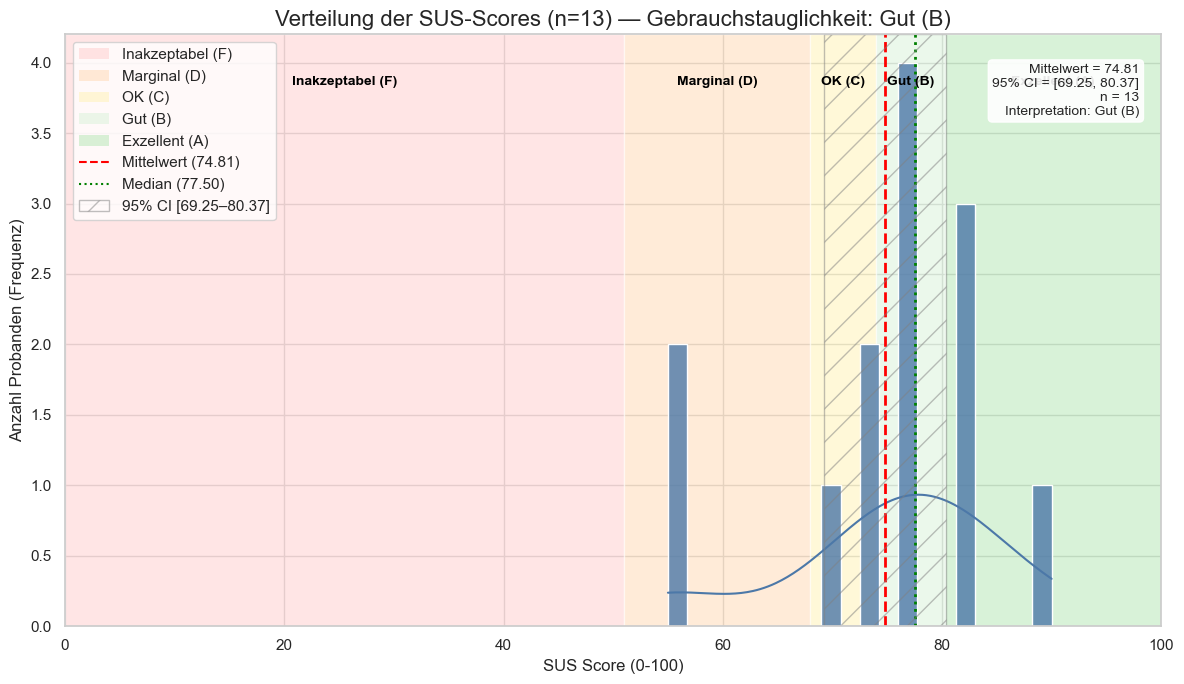

In [54]:
print("Erstelle verbessertes Verteilungsdiagramm mit Interpretations-Bändern...")
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 7))
# Definition der Interpretationsbereiche (Start, End, Farbe, Label)
bands = [
    (0, 51, '#ffcccc', 'Inakzeptabel (F)'),
    (51, 68, '#ffd9b3', 'Marginal (D)'),
    (68, 74, '#fff2b3', 'OK (C)'),
    (74, 80.3, '#d9f2d9', 'Gut (B)'),
    (80.3, 100, '#b3e6b3', 'Exzellent (A)')
]
# Hintergrund-Bänder zeichnen
for start, end, color, label in bands:
    ax.axvspan(start, end, facecolor=color, alpha=0.5)

# Zeichne Histogramm + KDE über die Bänder (auf die Achse ax)
viz = sns.histplot(data=df_calc, x='SUS_Score_0_100', bins=20, kde=True, alpha=0.8, ax=ax, color='#4c78a8')

# Jetzt y-Limits ermitteln für die Positionierung der Texte
ymin, ymax = ax.get_ylim()
y_text = ymax * 0.92
for start, end, color, label in bands:
    xpos = (start + end) / 2
    ax.text(xpos, y_text, label, ha='center', va='center', fontsize=10, color='black', weight='semibold')

# Vertikale Linien für Mittelwert (rot) und Median (grün) einzeichnen
ax.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mittelwert ({mean_score:.2f})')
ax.axvline(median_score, color='green', linestyle=':', linewidth=2, label=f'Median ({median_score:.2f})')

# Achsenbeschriftungen und Title
ax.set_title(f'Verteilung der SUS-Scores (n={n_count}) — Gebrauchstauglichkeit: {mean_label}', fontsize=16)
ax.set_xlabel('SUS Score (0-100)')
ax.set_ylabel('Anzahl Probanden (Frequenz)')
ax.set_xlim(0, 100)

# Legende mit Farbbändern und Linien
patch_handles = [mpatches.Patch(facecolor=color, edgecolor='none', alpha=0.5, label=label) for (_, _, color, label) in bands]
ci_patch = mpatches.Patch(facecolor='none', edgecolor='gray', hatch='/', alpha=0.5, label=f'95% CI [{ci_lower:.2f}–{ci_upper:.2f}]')
line_handles = [Line2D([0], [0], color='red', linestyle='--', label=f'Mittelwert ({mean_score:.2f})'),
                Line2D([0], [0], color='green', linestyle=':', label=f'Median ({median_score:.2f})')]
ax.legend(handles=patch_handles + line_handles + [ci_patch], loc='upper left')

# NEU: CI-Bereich als hellere, weniger dichte Schraffur zeichnen
ax.axvspan(ci_lower, ci_upper, facecolor='none', edgecolor='gray', hatch='/', alpha=0.5, zorder=2)

# Zusatz: Interpretation des Mittelwerts in Textbox (jetzt am Ende, um über allem zu liegen)
textbox = f"Mittelwert = {mean_score:.2f}\n95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]\nn = {n_count}\nInterpretation: {mean_label}"
ax.text(0.98, 0.95, textbox, transform=ax.transAxes, fontsize=10, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9), zorder=3)

plt.tight_layout()
plt.savefig('sus_score_distribution_interpreted.png', dpi=300, bbox_inches='tight')
plt.show()